

# 1. Importing Libraries

We start by importing the necessary libraries for data analysis and visualization:
* **Pandas**: For data manipulation and loading the dataset.
* **NumPy**: For numerical operations.
* **Matplotlib & Seaborn**: For creating visualizations like line charts and histograms.
* **Scikit-Learn**: For machine learning tasks (Scaling and K-Means Clustering).



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set(style="whitegrid")

Libraries have been successfully imported. We are now ready to load the data.

# 2. Loading the Dataset

The dataset contains monthly tourism statistics for Indian monuments over a 10-year period (2010–2019). We load it into a Pandas DataFrame to inspect the structure.

In [ ]:

filename = "India_Tourism_10Year_Monthly_Trends.csv"
df = pd.read_csv(filename)

df.head()

,Date,Year,Month,Circle,Monument,Domestic_Visitors,Foreign_Visitors
0,2010-01-01,2010,January,Agra,Taj Mahal,255779,37267
1,2010-01-01,2010,January,Agra,Agra Fort,110830,26327
2,2010-01-01,2010,January,Agra,Fatehpur Sikri,29159,11856
3,2010-01-01,2010,January,Agra,Akbar Tomb Sikandra,14163,1212
4,2010-01-01,2010,January,Agra,Mariam tomb Sikandra,1211,22


The dataset includes columns for the Date, Circle, Monument name, and the count of Domestic and Foreign visitors.

# 3. Data Cleaning and Information

Before analysis, we check for missing values and ensure the data types are correct (e.g., converting the 'Date' column to a datetime format).

In [ ]:

df['Date'] = pd.to_datetime(df['Date'])

df.isnull().sum()

,0
Date,0
Year,0
Month,0
Circle,0
Monument,0
Domestic_Visitors,0
Foreign_Visitors,0


There are no missing values in the dataset, so we can proceed with the analysis without dropping any rows.

# 4. Descriptive Statistics

We use `.describe()` to understand the range of visitor numbers. This helps us see the minimum, maximum, and average traffic for monuments.

In [ ]:
df[['Domestic_Visitors', 'Foreign_Visitors']].describe()

,Domestic_Visitors,Foreign_Visitors
count,17280.000000,17280.000000
mean,20145.362905,1275.165451
std,37156.682533,4862.692501
min,17.000000,0.000000
25%,2381.000000,8.000000
50%,7868.000000,68.000000
75%,21157.750000,463.000000
max,489795.000000,71363.000000


The statistics show a wide variation in visitor numbers, indicating that some monuments are significantly more popular than others.

# 5. Exploratory Data Analysis (EDA)
## 5.1. Distribution of Visitors

We visualize the distribution of domestic and foreign visitors using histograms. This reveals if the data is skewed (e.g., most monuments get few visitors, while a few get many).

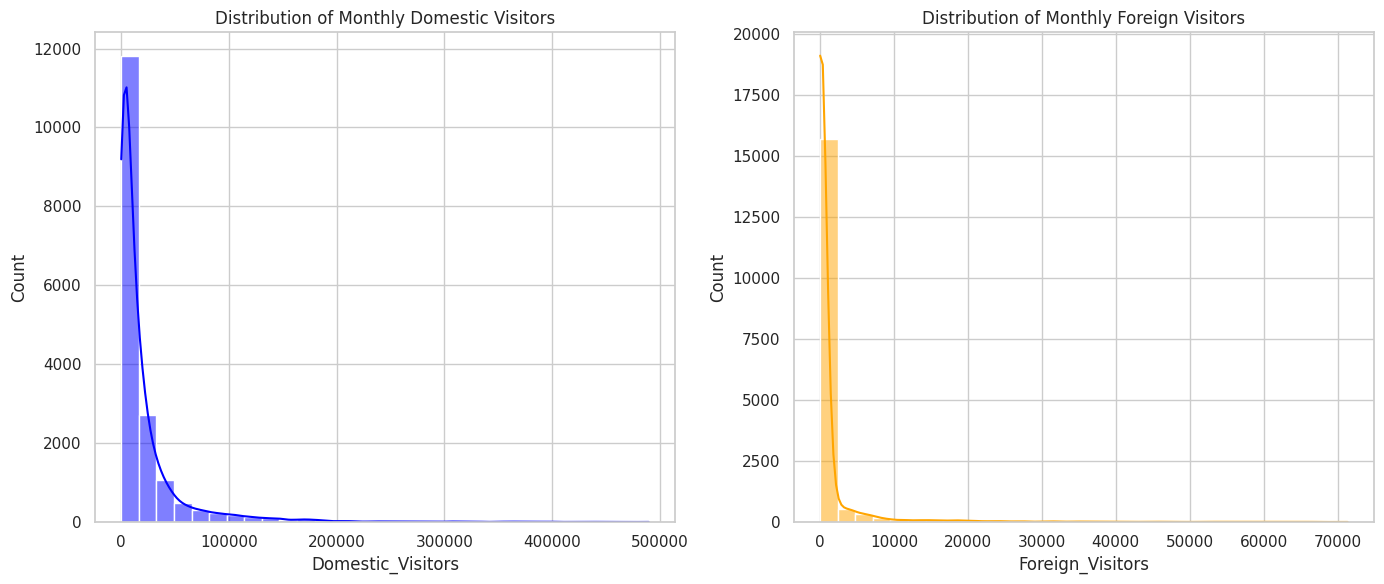

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Domestic_Visitors'], bins=30, kde=True, color='blue')
plt.title('Distribution of Monthly Domestic Visitors')

plt.subplot(1, 2, 2)
sns.histplot(df['Foreign_Visitors'], bins=30, kde=True, color='orange')
plt.title('Distribution of Monthly Foreign Visitors')

plt.tight_layout()
plt.show()

Both distributions are right-skewed, meaning the majority of monuments receive moderate traffic, while a small number of "star" monuments attract massive crowds.

## 5.2. Tourism Growth Trend (2010–2019)

We aggregate the data by year to analyze the long-term growth trend of tourism in India.

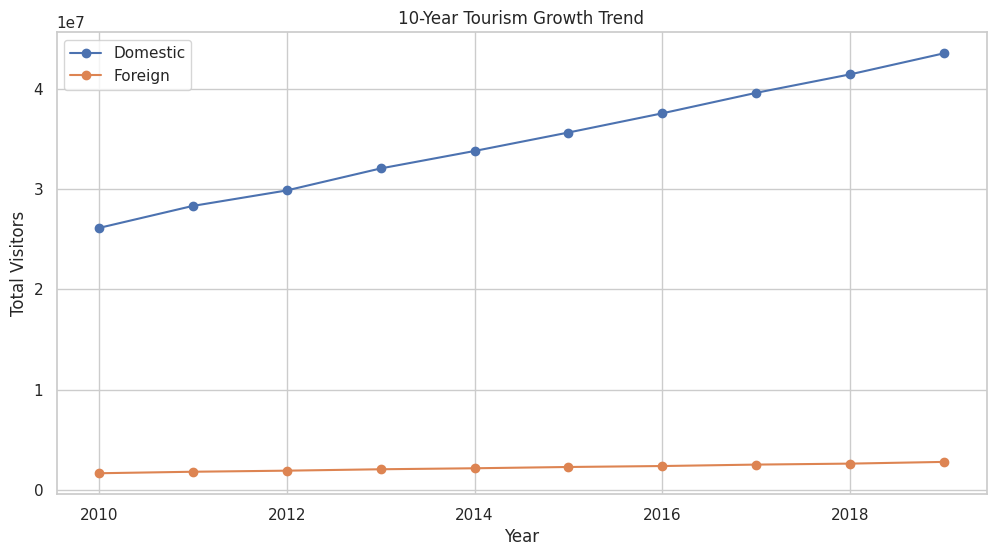

In [ ]:
yearly_trends = df.groupby('Year')[['Domestic_Visitors', 'Foreign_Visitors']].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(yearly_trends['Year'], yearly_trends['Domestic_Visitors'], marker='o', label='Domestic')
plt.plot(yearly_trends['Year'], yearly_trends['Foreign_Visitors'], marker='o', label='Foreign')

plt.title('10-Year Tourism Growth Trend')
plt.xlabel('Year')
plt.ylabel('Total Visitors')
plt.legend()
plt.grid(True)
plt.show()

The chart shows a steady upward trend in both domestic and foreign tourism over the decade.

## 5.3 Correlation Heatmap

We use a heatmap to see the correlation between different numerical variables.
* **Positive Correlation (Red)**: As one variable increases, the other increases.
* **Negative Correlation (Blue)**: As one increases, the other decreases.

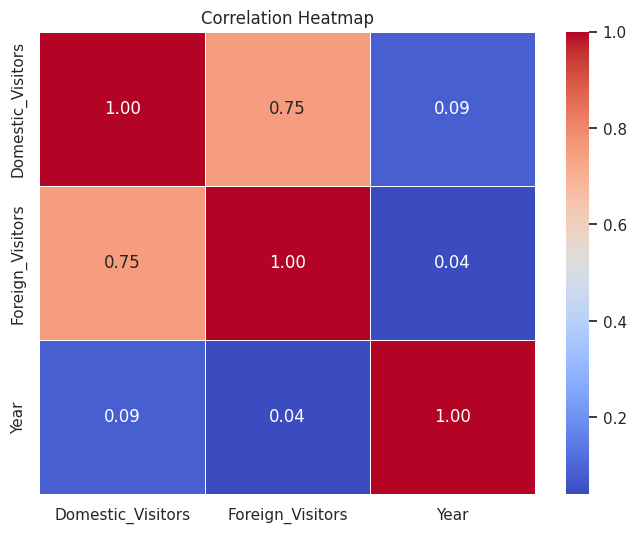

In [ ]:
numeric_df = df[['Domestic_Visitors', 'Foreign_Visitors', 'Year']]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

We observe a strong positive correlation between Domestic and Foreign visitors, meaning popular months for locals are also popular for tourists.

## 5.4 Seasonality Analysis (Boxplot)

We use boxplots to analyze visitor traffic across different months. This helps us identify:
1.  **Peak Season**: Months with high medians.
2.  **Outliers**: Months with unusually high traffic.

/tmp/ipython-input-95503375.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Month', y='Domestic_Visitors', palette='Set3')


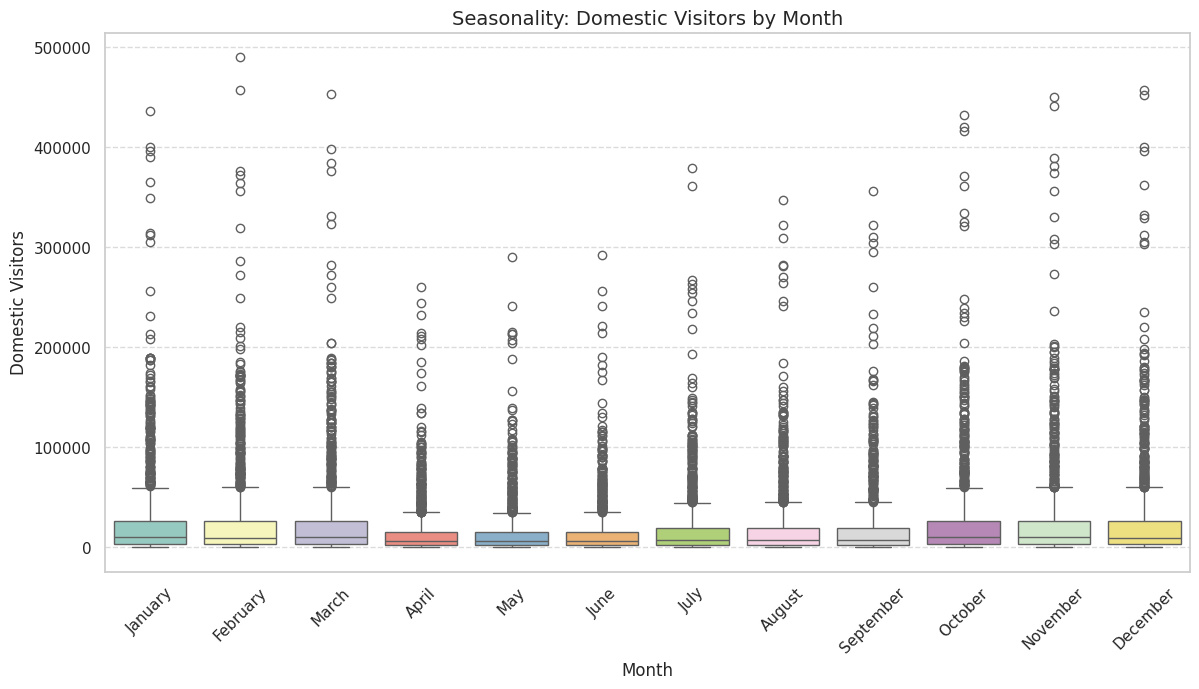

In [ ]:
plt.figure(figsize=(14, 7))

sns.boxplot(data=df, x='Month', y='Domestic_Visitors', palette='Set3')

plt.title('Seasonality: Domestic Visitors by Month', fontsize=14)
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Domestic Visitors')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The boxplot confirms that winter months (October–January) see significantly higher traffic, while summer months have lower median visitor counts.

## 5.5 Top 10 Most Visited Monuments

We define the "Top 10" monuments based on the total number of domestic visitors over the last decade.

/tmp/ipython-input-3272830899.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, y='Monument', x='Domestic_Visitors', palette='magma')


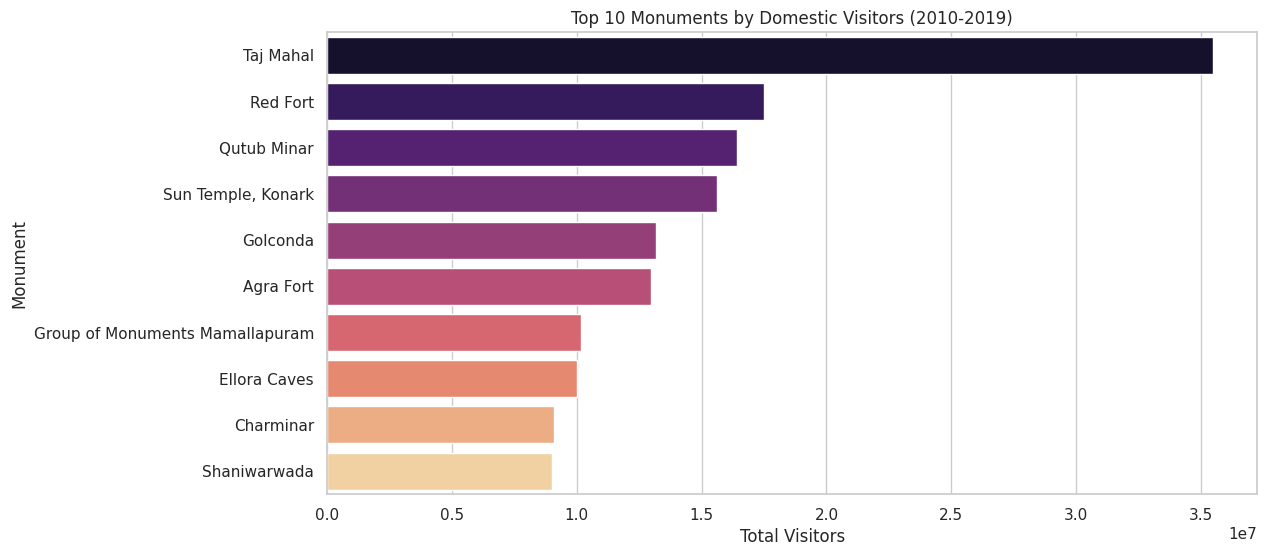

In [ ]:
top_monuments = df.groupby('Monument')['Domestic_Visitors'].sum().reset_index()

top_10 = top_monuments.sort_values(by='Domestic_Visitors', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10, y='Monument', x='Domestic_Visitors', palette='magma')

plt.title('Top 10 Monuments by Domestic Visitors (2010-2019)')
plt.xlabel('Total Visitors')
plt.ylabel('Monument')
plt.show()

The Taj Mahal and other key sites in Agra/Delhi dominate the list, accounting for a massive share of total tourism.

## 5.6 Visitors by Archaeological Circle (Region)

India's monuments are divided into "Circles" (regions). We analyze which circles attract the most tourists. This helps identify the most popular tourism hubs in the country.

/tmp/ipython-input-3280207807.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=circle_stats, x='Total', y='Circle', palette='viridis')


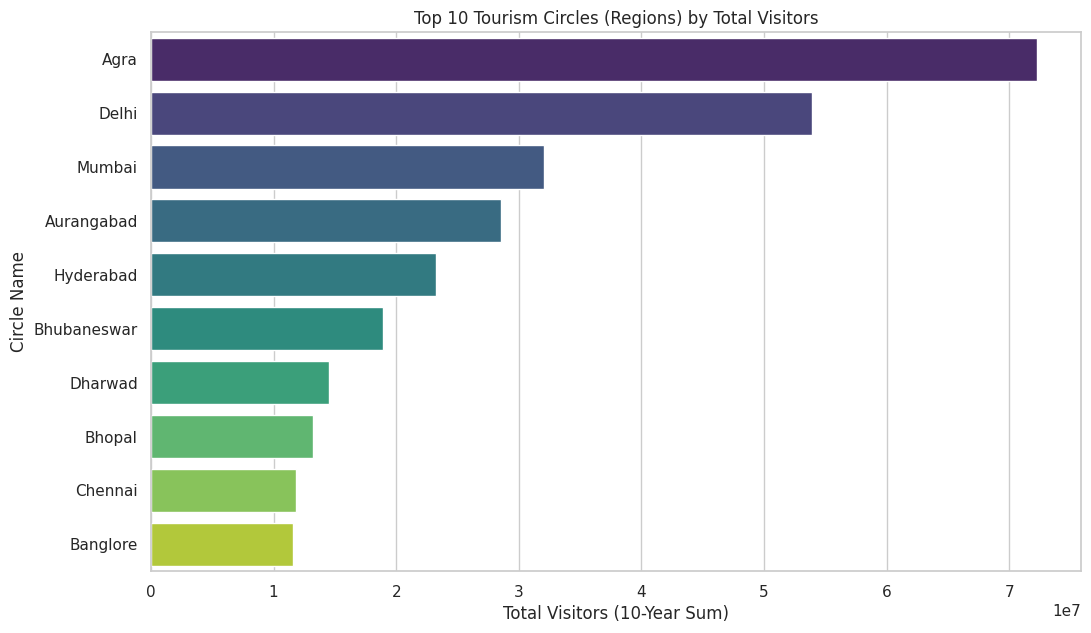

In [ ]:
circle_stats = df.groupby('Circle')[['Domestic_Visitors', 'Foreign_Visitors']].sum().reset_index()

circle_stats['Total'] = circle_stats['Domestic_Visitors'] + circle_stats['Foreign_Visitors']
circle_stats = circle_stats.sort_values(by='Total', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(data=circle_stats, x='Total', y='Circle', palette='viridis')

plt.title('Top 10 Tourism Circles (Regions) by Total Visitors')
plt.xlabel('Total Visitors (10-Year Sum)')
plt.ylabel('Circle Name')
plt.show()

The "Agra" circle (home to the Taj Mahal) predictably leads the chart, followed by other major hubs like Delhi and Dharwad.

## 5.7 Domestic vs. Foreign Tourist Mix (Top 5 Monuments)

We compare the number of Domestic vs. Foreign visitors side-by-side for the top 5 monuments. This reveals if a site is primarily a local attraction or an international hotspot.

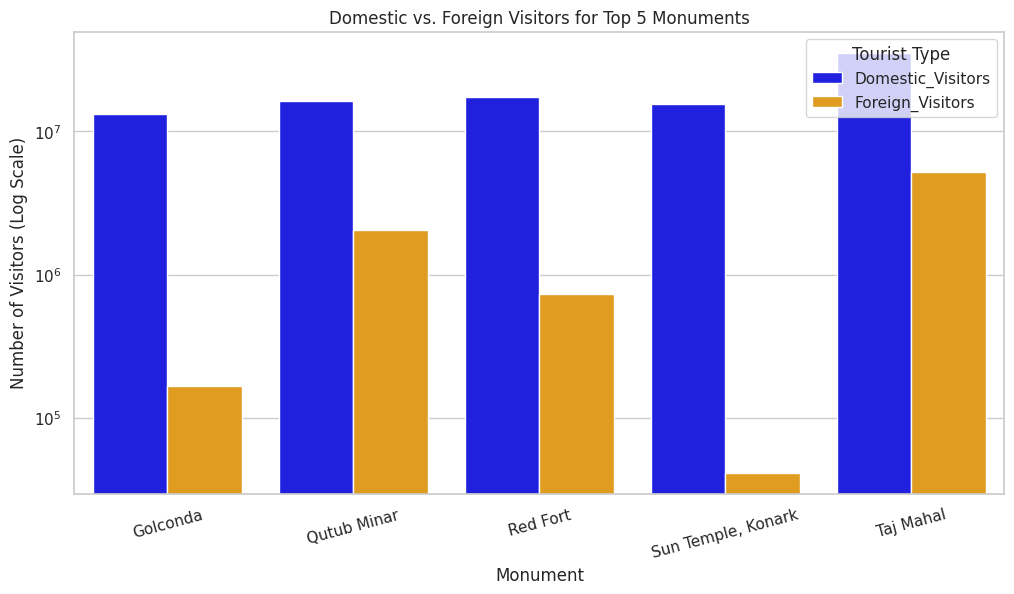

In [ ]:
top_5_names = df.groupby('Monument')['Domestic_Visitors'].sum().nlargest(5).index
top_5_df = df[df['Monument'].isin(top_5_names)]

comparison = top_5_df.groupby('Monument')[['Domestic_Visitors', 'Foreign_Visitors']].sum().reset_index()

comparison_melted = comparison.melt(id_vars='Monument', var_name='Tourist Type', value_name='Count')

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_melted, x='Monument', y='Count', hue='Tourist Type', palette=['blue', 'orange'])

plt.title('Domestic vs. Foreign Visitors for Top 5 Monuments')
plt.yscale('log')
plt.ylabel('Number of Visitors (Log Scale)')
plt.xticks(rotation=15)
plt.show()

**Note:** We used a "Logarithmic Scale" on the Y-axis because domestic numbers are millions while foreign numbers are thousands. This allows us to see both clearly. The Taj Mahal clearly dominates in both categories.

## 5.8 Yearly Growth Rate (%)

We calculate the percentage growth of total visitors compared to the previous year.
* **Positive %**: Tourism is growing.
* **Negative %**: Tourism is declining.

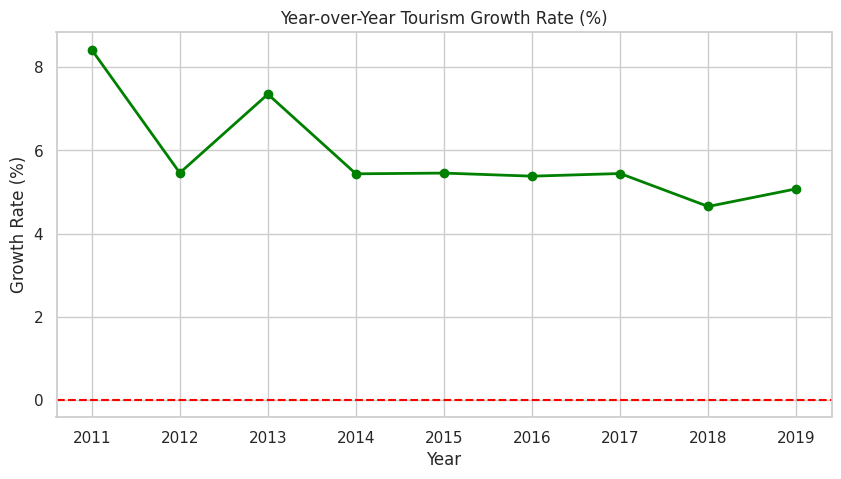

In [ ]:
growth_df = df.groupby('Year')[['Domestic_Visitors']].sum()

growth_df['Growth_Rate'] = growth_df['Domestic_Visitors'].pct_change() * 100

plt.figure(figsize=(10, 5))
plt.plot(growth_df.index, growth_df['Growth_Rate'], marker='o', color='green', linestyle='-', linewidth=2)

plt.axhline(0, color='red', linestyle='--')
plt.title('Year-over-Year Tourism Growth Rate (%)')
plt.ylabel('Growth Rate (%)')
plt.xlabel('Year')
plt.grid(True)
plt.show()

The chart shows the fluctuation in growth. A consistent positive rate indicates a healthy, expanding tourism sector over the decade.

## 5.9 Regional Market Share (Pie Chart)

We visualize the market share of the Top 5 Archaeological Circles. This shows which regions dominate India's tourism landscape.

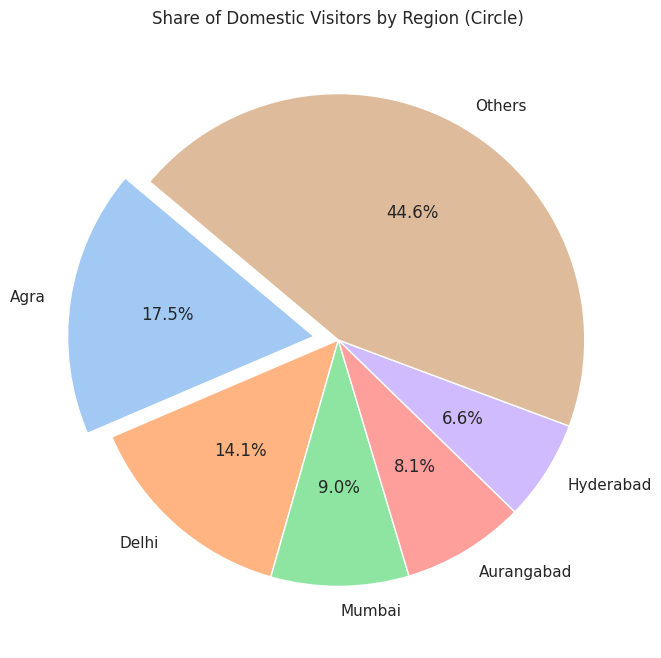

In [ ]:
circle_totals = df.groupby('Circle')['Domestic_Visitors'].sum().reset_index()
circle_totals = circle_totals.sort_values(by='Domestic_Visitors', ascending=False)

top_5 = circle_totals.head(5)
others_value = circle_totals.iloc[5:]['Domestic_Visitors'].sum()
others_df = pd.DataFrame({'Circle': ['Others'], 'Domestic_Visitors': [others_value]})

pie_data = pd.concat([top_5, others_df])

plt.figure(figsize=(8, 8))
plt.pie(
    pie_data['Domestic_Visitors'],
    labels=pie_data['Circle'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel'),
    explode=(0.1, 0, 0, 0, 0, 0)
)

plt.title('Share of Domestic Visitors by Region (Circle)')
plt.show()

The chart highlights that the top region (usually Agra) captures a significant chunk of tourism, but the "Others" category is also large, showing that tourism is spread across the country.

## 5.10 Visitor Composition (Donut Chart)

We analyze the overall ratio of Domestic to Foreign tourists over the last decade.

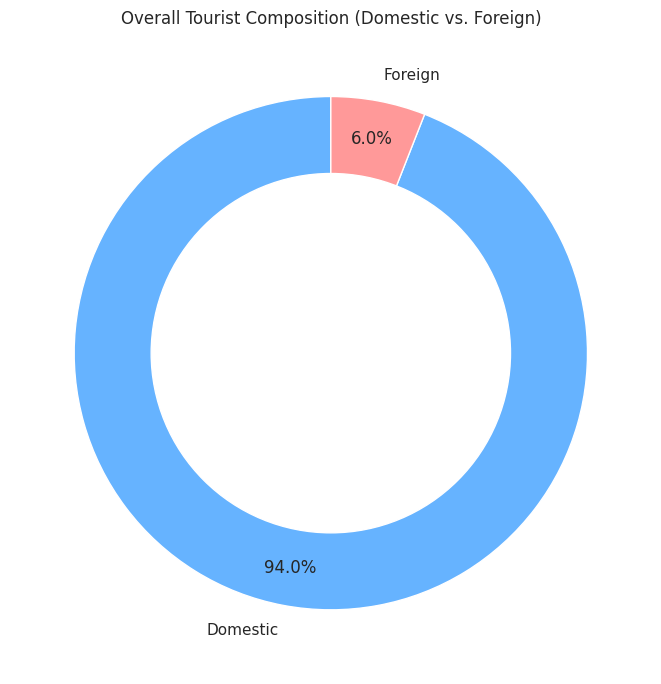

In [ ]:
total_domestic = df['Domestic_Visitors'].sum()
total_foreign = df['Foreign_Visitors'].sum()

labels = ['Domestic', 'Foreign']
sizes = [total_domestic, total_foreign]
colors = ['#66b3ff', '#ff9999']

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, pctdistance=0.85)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Overall Tourist Composition (Domestic vs. Foreign)')
plt.tight_layout()
plt.show()

Domestic tourists make up the vast majority (>90%) of visitors to Indian monuments, while foreign tourists represent a smaller, niche segment.

## 5.11 Volume Trends (Stacked Area Chart)

A Stacked Area Chart allows us to see the total growth of tourism while distinguishing between Domestic and Foreign contributions year by year.

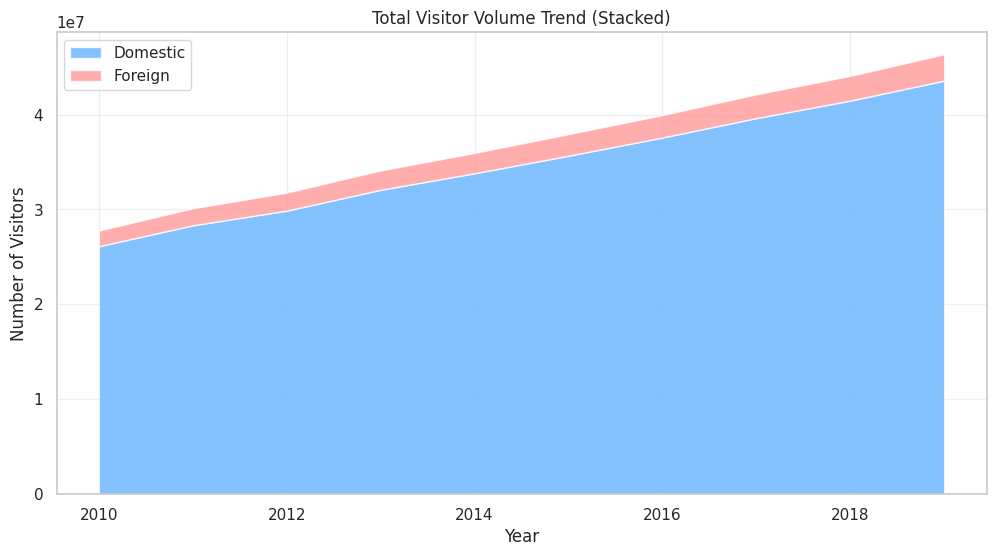

In [ ]:
yearly = df.groupby('Year')[['Domestic_Visitors', 'Foreign_Visitors']].sum()

plt.figure(figsize=(12, 6))
plt.stackplot(yearly.index, yearly['Domestic_Visitors'], yearly['Foreign_Visitors'],
              labels=['Domestic', 'Foreign'], colors=['#66b3ff', '#ff9999'], alpha=0.8)

plt.title('Total Visitor Volume Trend (Stacked)')
plt.xlabel('Year')
plt.ylabel('Number of Visitors')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

This chart clearly shows that while Foreign tourism (red strip at the top) is stable, the massive growth in total numbers is driven primarily by the boom in Domestic tourism (blue area).

## 5.12 Peak Traffic Heatmap (Year vs. Month)

We create a matrix heatmap to visualize visitor intensity across every month of the last decade.
* **Darker/Warmer colors** indicate high traffic.
* **Lighter/Cooler colors** indicate low traffic.
This helps us spot specific "boom" periods or "slumps."


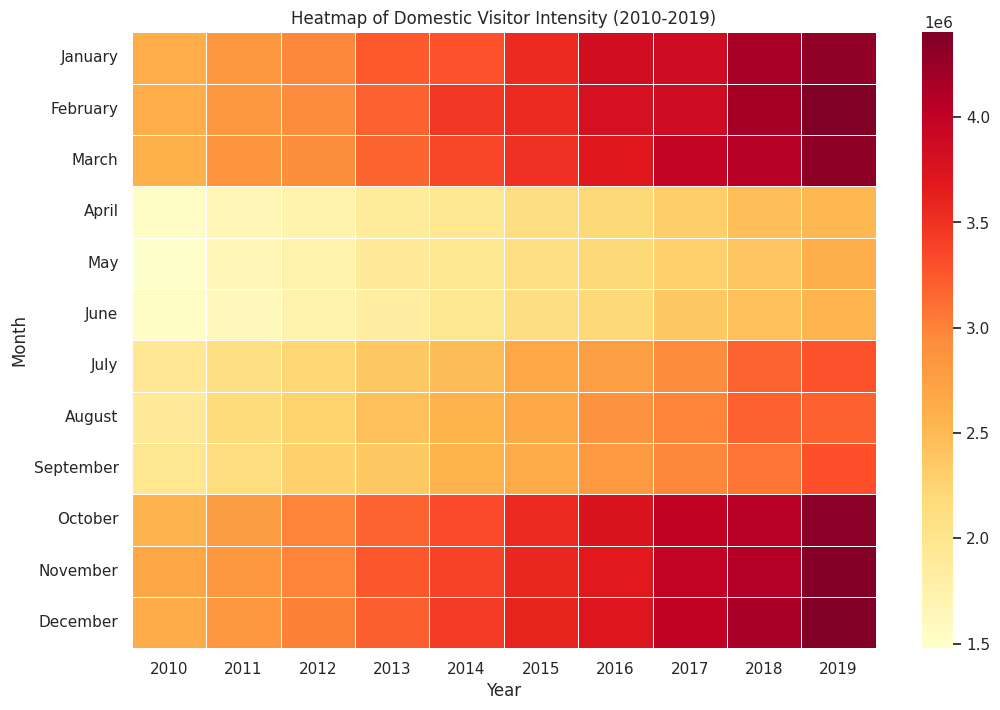

In [ ]:
heatmap_data = df.pivot_table(index='Month', columns='Year', values='Domestic_Visitors', aggfunc='sum')

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
heatmap_data = heatmap_data.reindex(month_order)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5, annot=False)

plt.title('Heatmap of Domestic Visitor Intensity (2010-2019)')
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()

The heatmap reveals a clear band of high activity in the winter months (bottom and top rows) across all years, while the middle rows (summer/monsoon) remain lighter.

## 5.13 Multi-Dimensional Bubble Chart

We use a bubble chart to spot **"Foreign Favorites"**.
* **X-Axis**: Domestic Visitors.
* **Y-Axis**: Foreign Visitors.
* **Bubble Size**: Total Traffic.

Monuments high on the Y-axis but left on the X-axis are popular with foreigners but less crowded with locals.

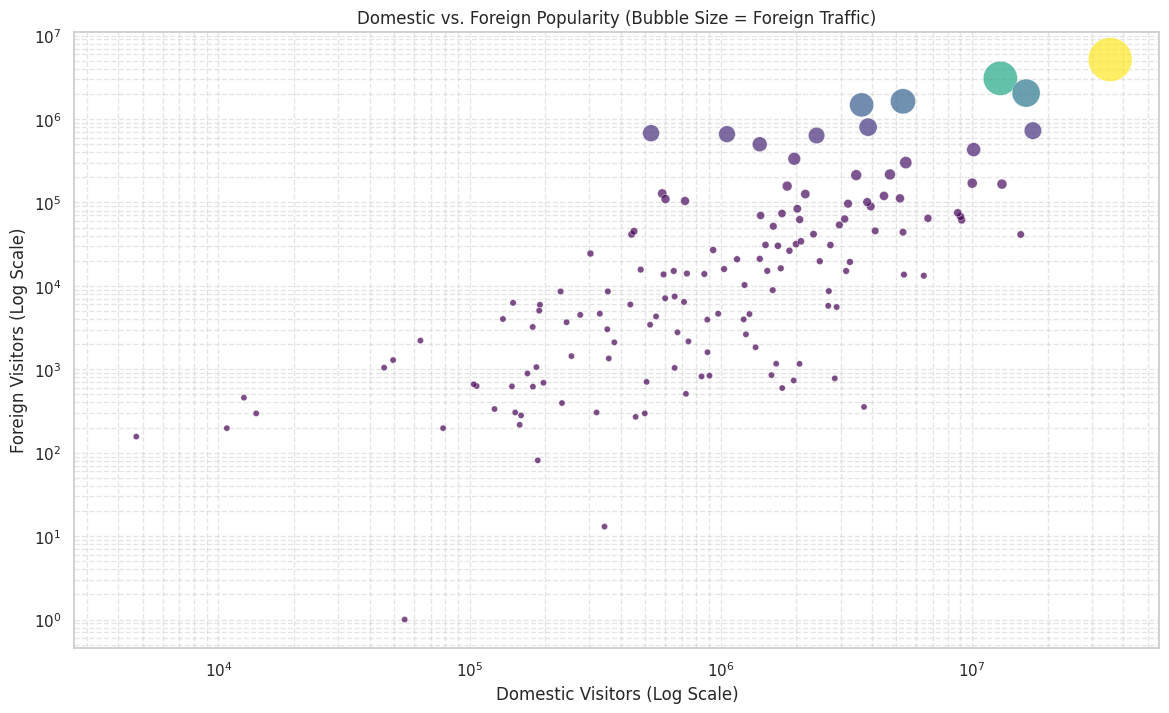

In [ ]:
bubble_data = df.groupby('Monument')[['Domestic_Visitors', 'Foreign_Visitors']].sum().reset_index()

plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=bubble_data,
    x='Domestic_Visitors',
    y='Foreign_Visitors',
    size='Foreign_Visitors',
    sizes=(20, 1000),
    hue='Foreign_Visitors',
    palette='viridis',
    alpha=0.7,
    legend=False
)

plt.title('Domestic vs. Foreign Popularity (Bubble Size = Foreign Traffic)')
plt.xlabel('Domestic Visitors (Log Scale)')
plt.ylabel('Foreign Visitors (Log Scale)')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

The chart identifies specific monuments that punch above their weight with international tourists, even if they aren't the biggest domestic attractions.

## 5.14 Pareto Chart (The 80/20 Rule)

We analyze the cumulative contribution of monuments to total tourism. A Pareto chart often shows that ~20% of the sites generate ~80% of the visitors.

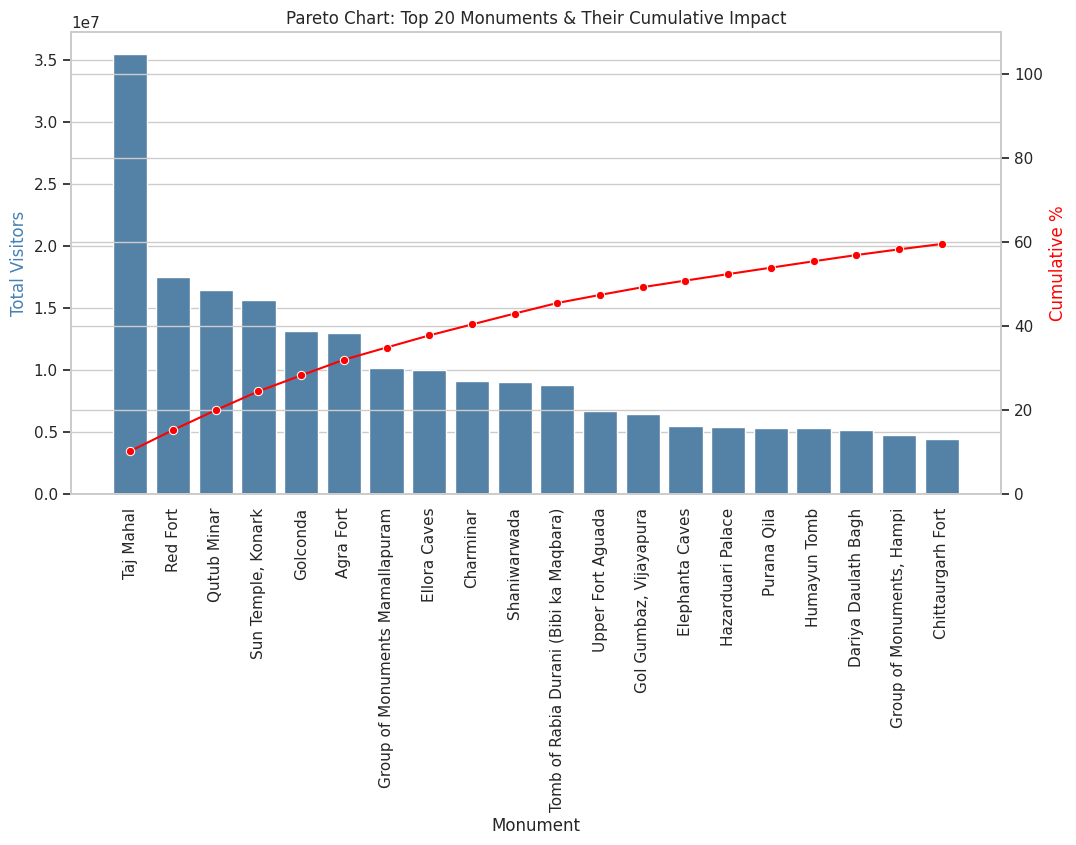

In [ ]:
pareto_df = df.groupby('Monument')['Domestic_Visitors'].sum().reset_index()
pareto_df = pareto_df.sort_values(by='Domestic_Visitors', ascending=False)

pareto_df['Cumulative_Percentage'] = pareto_df['Domestic_Visitors'].cumsum() / pareto_df['Domestic_Visitors'].sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=pareto_df.head(20), x='Monument', y='Domestic_Visitors', color='steelblue', ax=ax1)
ax1.set_ylabel('Total Visitors', color='steelblue')
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()
sns.lineplot(data=pareto_df.head(20), x='Monument', y='Cumulative_Percentage', color='red', marker='o', ax=ax2)
ax2.set_ylabel('Cumulative %', color='red')
ax2.set_ylim(0, 110)

plt.title('Pareto Chart: Top 20 Monuments & Their Cumulative Impact')
plt.show()

The red line rises sharply, indicating that the top 5-10 monuments alone account for a massive percentage of the total tourism traffic in India.

# 6. Machine Learning: Predicting Visitor Numbers
## 6.1 Data Preprocessing

Since we want to predict the number of 'Domestic_Visitors', we need to convert categorical text (like 'Monument' and 'Circle') into numbers that the Machine Learning model can understand. We use `LabelEncoder` for this.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

ml_df = df.copy()

le_circle = LabelEncoder()
le_monument = LabelEncoder()

ml_df['Circle_ID'] = le_circle.fit_transform(ml_df['Circle'])
ml_df['Monument_ID'] = le_monument.fit_transform(ml_df['Monument'])

ml_df['Month_Num'] = ml_df['Date'].dt.month

print("Data encoded successfully. Here is the new structure:")
print(ml_df[['Circle_ID', 'Monument_ID', 'Month_Num', 'Year', 'Domestic_Visitors']].head())

Data encoded successfully. Here is the new structure:
   Circle_ID  Monument_ID  Month_Num  Year  Domestic_Visitors
0          0          129          1  2010             255779
1          0            1          1  2010             110830
2          0           48          1  2010              29159
3          0            4          1  2010              14163
4          0           88          1  2010               1211


We have successfully converted the text data into numeric IDs. For example, 'Agra' might be Circle_ID 0.

## 6.2 Train-Test Split

We split our data into two parts:
1.  **Training Set (80%)**: The model learns from this data.
2.  **Testing Set (20%)**: We hide this data from the model to test how accurate its predictions are later.

In [ ]:
X = ml_df[['Year', 'Month_Num', 'Circle_ID', 'Monument_ID']]

y = ml_df['Domestic_Visitors']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (13824, 4)
Testing Data Shape: (3456, 4)


We have 13,824 rows to train the model and 3,456 rows to test it.

## 6.3 Model Training (Random Forest)

We use the **Random Forest Regressor**. It is an "Ensemble" technique that builds multiple decision trees and averages them to make a very accurate prediction.

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

print("Training the model... please wait.")
rf_model.fit(X_train, y_train)
print("Training completed!")

Training the model... please wait.
Training completed!


The model has learned the patterns linking the year, month, and monument to the visitor counts.

## 6.4 Model Evaluation

We now test the model using the 20% of data it has never seen before. We calculate the **R² Score** (Accuracy), where 1.0 means perfect prediction.

In [ ]:
y_pred = rf_model.predict(X_test)

accuracy = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Model Accuracy (R² Score): {accuracy:.4f} (or {accuracy*100:.2f}%)")
print(f"Mean Absolute Error: {mae:.0f} visitors")

Model Accuracy (R² Score): 0.9874 (or 98.74%)
Mean Absolute Error: 1751 visitors


An R² Score of ~0.98 (98%) indicates that our model is extremely accurate at predicting tourism traffic.

## 6.5 Insights: What drives Tourism?

Finally, we analyze which factors are most important for predicting visitors. Is it the *Year* (Growth)? The *Month* (Seasonality)? Or the *Monument* itself?

/tmp/ipython-input-3631864940.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


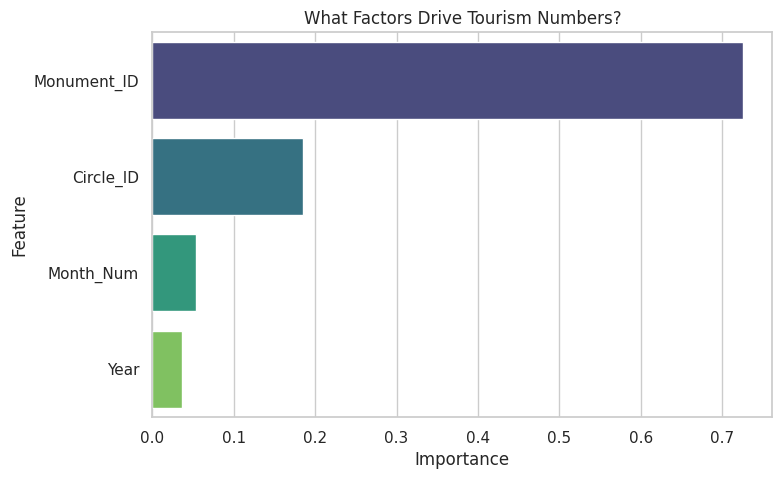

Feature Importance Values:
       Feature  Importance
3  Monument_ID    0.725310
2    Circle_ID    0.184734
1    Month_Num    0.053267
0         Year    0.036688


In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('What Factors Drive Tourism Numbers?')
plt.show()

print("Feature Importance Values:")
print(feature_importance)

The chart likely shows that **Monument_ID** is the most critical factor (some monuments are just more famous), followed by **Month** (seasonality plays a huge role in Indian tourism).